# LOAD

In [15]:
import numpy as np
import pickle as pkl
import os
import pandas as pd

#load numpy pickle
def load_pickle(file):
    with open(file, 'rb') as f:
        data = pkl.load(f)
    return data

df_csv = pd.read_csv("../data/r2_cleaned.csv")
df_b2 = df_csv[df_csv["BLOCK"] == 2]
#ensure all answers in block 2 are in the format of a string 
df_b2["ANSWER"] = df_b2["ANSWER"].fillna("nan").astype(str)
df_b2.groupby("ANSWER").size()

ANSWER
1       894
10     1111
2      1231
3      5033
4      2315
5      2379
6      2714
7      2832
8      2615
9       857
nan      19
dtype: int64

In [16]:
data_qwen = load_pickle("../external_embeds/qwen3emb4b_batch1_r2_embeddings_cache_keyed.pkl")
data_allmpnet_b32 = load_pickle("../external_embeds/allmpnet_batch32_r2_embeddings_cache_keyed.pkl")
data_allmpnet_b1 = load_pickle("../external_embeds/allmpnet_batch1_r2_embeddings_cache_keyed.pkl")

In [17]:
# embd1 = data[("human_lima_4","Robusto2_153",19,1)]
# embd2 = data[("human_lima_7","Robusto2_82",19,1)]
def get_key(row):
    return (row["AGENT"], row["VIDEO"], row["QUESTION_NUM"], row["REPETITION"])

def check_embeds(data, df_csv):
    unique_answers_b2 = df_csv["ANSWER"].unique()
    print(f"Unique answers in block 2: {unique_answers_b2}")
    for i in unique_answers_b2:
        print(f"Checking for answer {i}")
        check = df_csv[df_csv["ANSWER"] == i].reset_index()
        check
        #check if all the embeds are equal
        embeddings = []
        for index, row in check.iterrows():
            key = get_key(row)
            if key in data:
                embeddings.append(data[key])
            else:
                print(f"Key {key} not found in data")
        embeddings = np.array(embeddings)

        #check if all the embeds are equal using L2 norm
        for i in range(len(embeddings)-1):
            distance = np.linalg.norm(embeddings[i] - embeddings[i+1])
            if np.linalg.norm(embeddings[i] - embeddings[i+1]) > 1e-6:
                print(embeddings[i][:3], embeddings[i+1][:3])
                print(f"Embeddings at index {i} and {i+1} are NOT equal with distance {distance}")
                return
            #else:
            #    print(f"Distance between embeddings at index {i} and {i+1}: {distance}")
        print("All embeddings aproxmately equal within the threshold")

In [18]:
print("Checking Qwen3emb4b embeddings")
check_embeds(data_qwen, df_b2)
print("Checking AllMPNet embeddings")
check_embeds(data_allmpnet_b1, df_b2)

Checking Qwen3emb4b embeddings
Unique answers in block 2: <ArrowStringArray>
['4', '3', '5', '9', '7', '6', '8', '2', '10', '1', 'nan']
Length: 11, dtype: str
Checking for answer 4
All embeddings aproxmately equal within the threshold
Checking for answer 3
All embeddings aproxmately equal within the threshold
Checking for answer 5
All embeddings aproxmately equal within the threshold
Checking for answer 9
All embeddings aproxmately equal within the threshold
Checking for answer 7
All embeddings aproxmately equal within the threshold
Checking for answer 6
All embeddings aproxmately equal within the threshold
Checking for answer 8
All embeddings aproxmately equal within the threshold
Checking for answer 2
All embeddings aproxmately equal within the threshold
Checking for answer 10
All embeddings aproxmately equal within the threshold
Checking for answer 1
All embeddings aproxmately equal within the threshold
Checking for answer nan
All embeddings aproxmately equal within the threshold
Ch

# TESTS DISTANCE

In [12]:
def compute_std_per_answer(data, df_csv):
    """Calcula el std dentro de cada respuesta única"""
    unique_answers = df_csv["ANSWER"].dropna().unique()
    stats = {}

    for answer in unique_answers:
        check = df_csv[df_csv["ANSWER"] == answer]
        embeddings = []

        for index, row in check.iterrows():
            key = get_key(row)
            if key in data:
                embeddings.append(data[key])

        if len(embeddings) > 0:
            embeddings = np.array(embeddings)
            mean_embed = np.mean(embeddings, axis=0)
            std_embed = np.std(embeddings, axis=0)
            mean_std = np.mean(std_embed)
            stats[answer] = {
                "count": len(embeddings),
                "mean_std": mean_std,
                "std_per_dim": std_embed
            }

    return stats

def compute_distance_matrix(data, df_csv):
    """Calcula la matriz de distancias (cosine) entre embeddings de diferentes respuestas"""
    from sklearn.metrics.pairwise import cosine_distances

    unique_answers = df_csv["ANSWER"].dropna().unique()
    answer_embeddings = {}

    for answer in unique_answers:
        check = df_csv[df_csv["ANSWER"] == answer]
        embeddings = []

        for index, row in check.iterrows():
            key = get_key(row)
            if key in data:
                embeddings.append(data[key])

        if len(embeddings) > 0:
            embeddings = np.array(embeddings)
            answer_embeddings[answer] = np.mean(embeddings, axis=0)

    if len(answer_embeddings) == 0:
        return None

    answers_sorted = sorted(answer_embeddings.keys())
    embeds = np.array([answer_embeddings[a] for a in answers_sorted])
    distances = cosine_distances(embeds)

    return distances, answers_sorted

def plot_heatmap(distances, answers_sorted):
    """Visualiza la matriz de distancias como heatmap"""
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(10, 8))
    sns.heatmap(distances, xticklabels=answers_sorted, yticklabels=answers_sorted,
                cmap='viridis', annot=True, fmt='.3f', cbar_kws={'label': 'Cosine Distance'})
    plt.title('Distancia entre embeddings de respuestas únicas')
    plt.tight_layout()
    plt.show()

def plot_std_bars(stats):
    """Visualiza el std promedio por respuesta"""
    import matplotlib.pyplot as plt

    answers = sorted(stats.keys())
    mean_stds = [stats[a]["mean_std"] for a in answers]
    counts = [stats[a]["count"] for a in answers]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.bar(answers, mean_stds)
    ax1.set_ylabel('Mean Standard Deviation')
    ax1.set_xlabel('Answer')
    ax1.set_title('Std por respuesta (dentro de la misma respuesta)')
    ax1.grid(axis='y', alpha=0.3)

    ax2.bar(answers, counts)
    ax2.set_ylabel('Count')
    ax2.set_xlabel('Answer')
    ax2.set_title('Número de samples por respuesta')
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

QWEN3EMB4B ANALYSIS
Qwen stats found for 11 respuestas
Answer 1: count=894, mean_std=0.0000000000
Answer 10: count=1111, mean_std=0.0000000000
Answer 2: count=1231, mean_std=0.0000000000
Answer 3: count=5033, mean_std=0.0000000000
Answer 4: count=2315, mean_std=0.0000000000
Answer 5: count=2379, mean_std=0.0000000000
Answer 6: count=2714, mean_std=0.0000000000
Answer 7: count=2832, mean_std=0.0000000000
Answer 8: count=2615, mean_std=0.0000000000
Answer 9: count=857, mean_std=0.0000000000
Answer nan: count=19, mean_std=0.0000000000

Distancia matrix Qwen (primeros valores):
[[0.         0.25213552 0.09663588]
 [0.25213552 0.         0.30626172]
 [0.09663588 0.30626172 0.        ]]


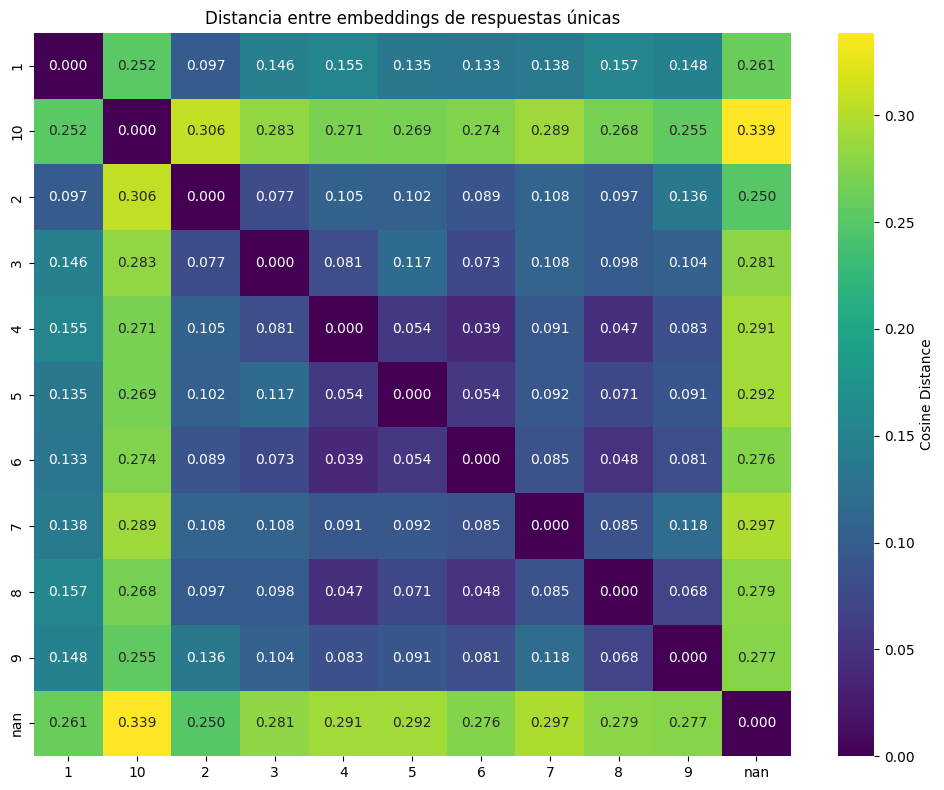

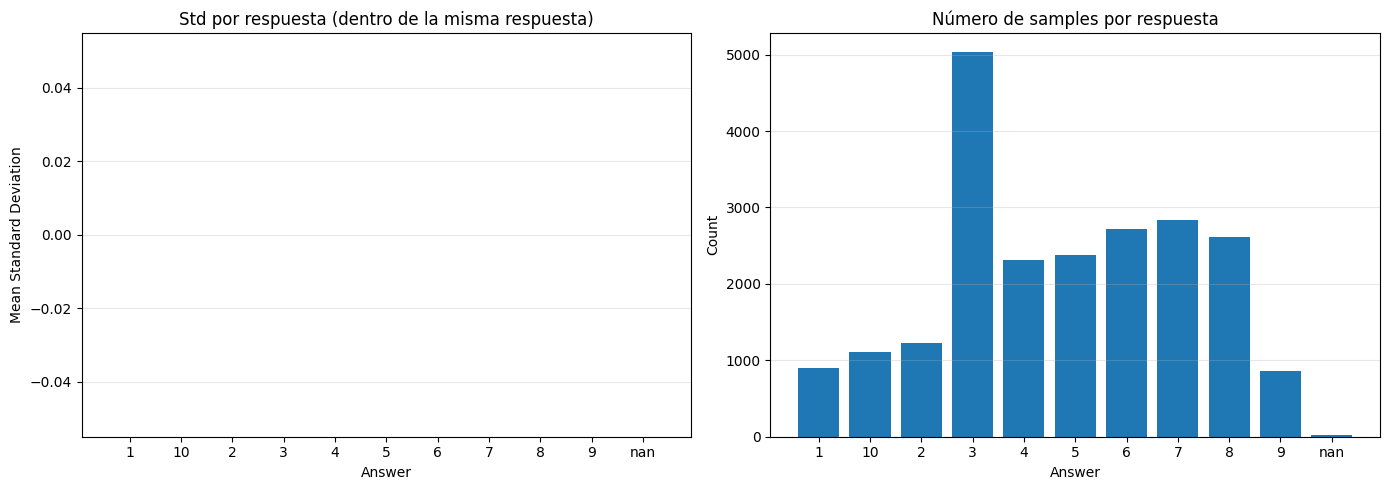


ALLMPNET ANALYSIS
AllMPNet stats found for 11 respuestas
Answer 1: count=894, mean_std=0.0000001557
Answer 10: count=1111, mean_std=0.0000001994
Answer 2: count=1231, mean_std=0.0000002097
Answer 3: count=5033, mean_std=0.0000009303
Answer 4: count=2315, mean_std=0.0000004268
Answer 5: count=2379, mean_std=0.0000004438
Answer 6: count=2714, mean_std=0.0000004946
Answer 7: count=2832, mean_std=0.0000004937
Answer 8: count=2615, mean_std=0.0000004593
Answer 9: count=857, mean_std=0.0000001485
Answer nan: count=19, mean_std=0.0000000032

Distancia matrix AllMPNet (primeros valores):
[[0.         0.45854402 0.2241571 ]
 [0.45854402 0.         0.50518775]
 [0.2241571  0.50518775 0.        ]]


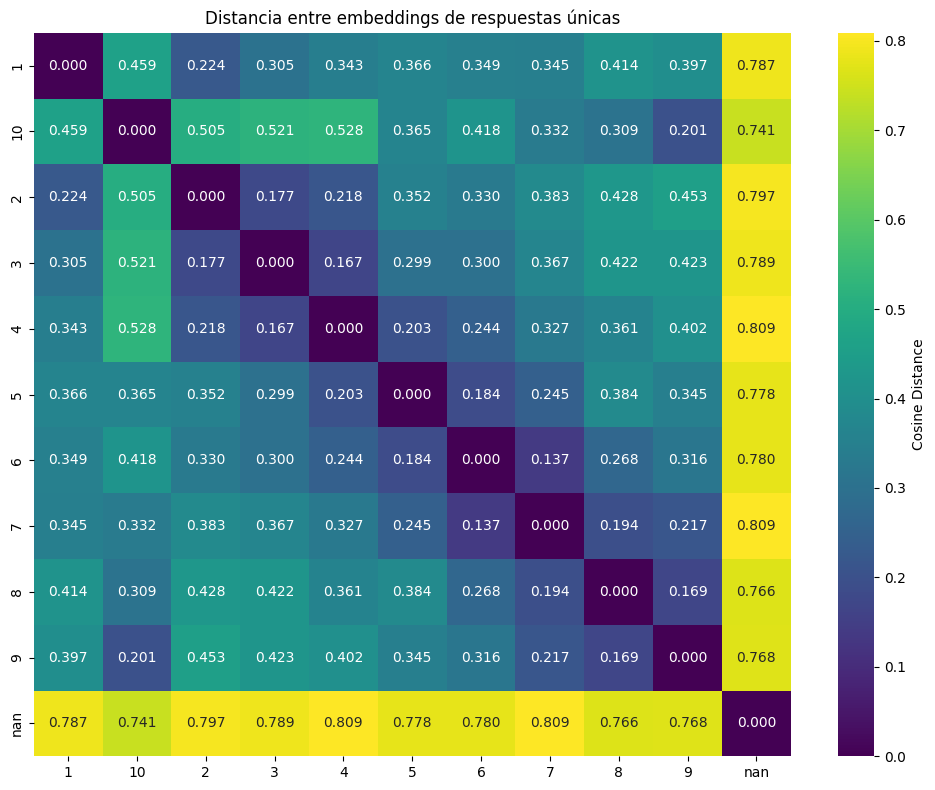

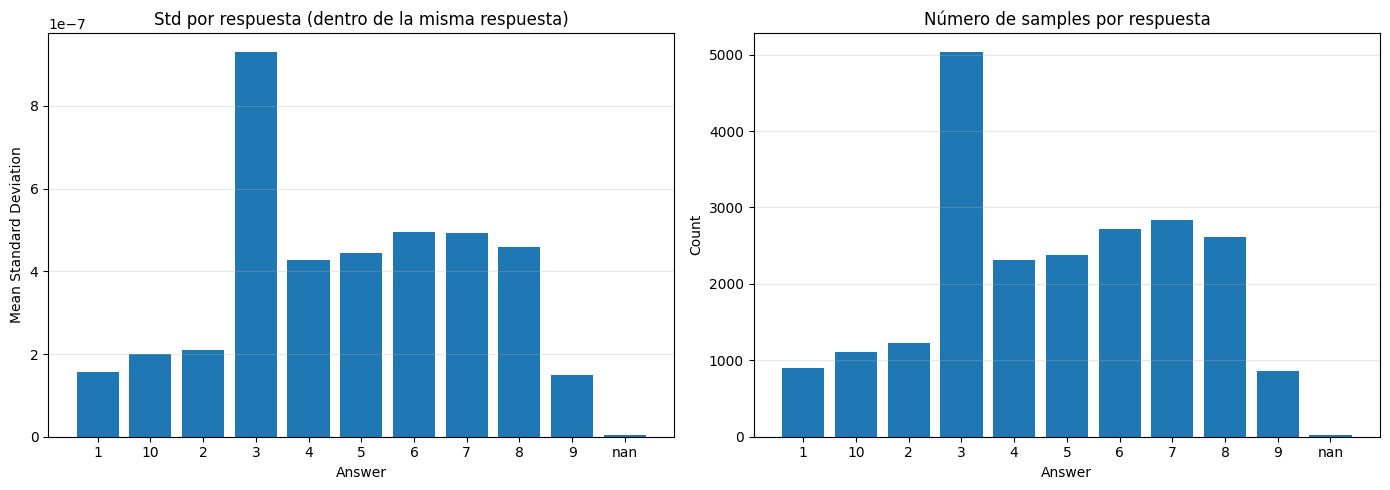


COMPARISON
Qwen mean_stds: ['0.00e+00', '0.00e+00', '0.00e+00', '0.00e+00', '0.00e+00', '0.00e+00', '0.00e+00', '0.00e+00', '0.00e+00', '0.00e+00', '0.00e+00']
AllMPNet mean_stds: ['1.56e-07', '1.99e-07', '2.10e-07', '9.30e-07', '4.27e-07', '4.44e-07', '4.95e-07', '4.94e-07', '4.59e-07', '1.49e-07', '3.16e-09']


In [13]:
print("="*50)
print("QWEN3EMB4B ANALYSIS")
print("="*50)

stats_qwen = compute_std_per_answer(data_qwen, df_b2)
print(f"Qwen stats found for {len(stats_qwen)} respuestas")
for answer, stat in sorted(stats_qwen.items()):
    print(f"Answer {answer}: count={stat['count']}, mean_std={stat['mean_std']:.10f}")

distances_qwen, answers_qwen = compute_distance_matrix(data_qwen, df_b2)
if distances_qwen is not None:
    print("\nDistancia matrix Qwen (primeros valores):")
    print(distances_qwen[:3, :3])
    plot_heatmap(distances_qwen, answers_qwen)
else:
    print("No distance matrix calculated for Qwen")

plot_std_bars(stats_qwen)

print("\n" + "="*50)
print("ALLMPNET ANALYSIS")
print("="*50)

stats_allmpnet = compute_std_per_answer(data_allmpnet_b1, df_b2)
print(f"AllMPNet stats found for {len(stats_allmpnet)} respuestas")
for answer, stat in sorted(stats_allmpnet.items()):
    print(f"Answer {answer}: count={stat['count']}, mean_std={stat['mean_std']:.10f}")

distances_allmpnet, answers_allmpnet = compute_distance_matrix(data_allmpnet_b1, df_b2)
if distances_allmpnet is not None:
    print("\nDistancia matrix AllMPNet (primeros valores):")
    print(distances_allmpnet[:3, :3])
    plot_heatmap(distances_allmpnet, answers_allmpnet)
else:
    print("No distance matrix calculated for AllMPNet")

plot_std_bars(stats_allmpnet)

print("\n" + "="*50)
print("COMPARISON")
print("="*50)
qwen_stds = [f"{stats_qwen[a]['mean_std']:.2e}" for a in sorted(stats_qwen.keys())]
allmpnet_stds = [f"{stats_allmpnet[a]['mean_std']:.2e}" for a in sorted(stats_allmpnet.keys())]
print(f"Qwen mean_stds: {qwen_stds}")
print(f"AllMPNet mean_stds: {allmpnet_stds}")

In [14]:
# Checar TODAS las respuestas en ambos modelos
def check_all_answers(data, df_csv, label):
    unique_answers = df_csv["ANSWER"].unique()
    #ensure all unique answers are strings
    unique_answers = [str(a) for a in unique_answers]
    print(f"\n{label}:")
    for answer in sorted(unique_answers):
        check = df_csv[df_csv["ANSWER"] == answer]
        embeddings = []
        for index, row in check.iterrows():
            key = get_key(row)
            if key in data:
                embeddings.append(data[key])
        embeddings = np.array(embeddings)
        
        if len(embeddings) > 1:
            std = np.std(embeddings, axis=0)
            mean_std = np.mean(std)
            max_dist = max(np.linalg.norm(embeddings[i] - embeddings[i+1]) for i in range(len(embeddings)-1))
            print(f"  answer='{answer}': n={len(embeddings)}, max_dist={max_dist:.2e}, mean_std={mean_std:.2e}, all_equal={np.all(std == 0)}")
        else:
            print(f"  answer='{answer}': solo {len(embeddings)} embedding(s), no se puede comparar")

check_all_answers(data_qwen, df_b2, "Qwen")
check_all_answers(data_allmpnet_b32, df_b2, "AllMPNet-b32")
check_all_answers(data_allmpnet_b1, df_b2, "AllMPNet-b1")


Qwen:
  answer='1': n=894, max_dist=0.00e+00, mean_std=0.00e+00, all_equal=True
  answer='10': n=1111, max_dist=0.00e+00, mean_std=0.00e+00, all_equal=True
  answer='2': n=1231, max_dist=0.00e+00, mean_std=0.00e+00, all_equal=True
  answer='3': n=5033, max_dist=0.00e+00, mean_std=0.00e+00, all_equal=True
  answer='4': n=2315, max_dist=0.00e+00, mean_std=0.00e+00, all_equal=True
  answer='5': n=2379, max_dist=0.00e+00, mean_std=0.00e+00, all_equal=True
  answer='6': n=2714, max_dist=0.00e+00, mean_std=0.00e+00, all_equal=True
  answer='7': n=2832, max_dist=0.00e+00, mean_std=0.00e+00, all_equal=True
  answer='8': n=2615, max_dist=0.00e+00, mean_std=0.00e+00, all_equal=True
  answer='9': n=857, max_dist=0.00e+00, mean_std=0.00e+00, all_equal=True
  answer='nan': n=19, max_dist=0.00e+00, mean_std=0.00e+00, all_equal=True

AllMPNet-b32:
  answer='1': n=894, max_dist=8.23e-07, mean_std=1.55e-07, all_equal=False
  answer='10': n=1111, max_dist=8.93e-07, mean_std=1.96e-07, all_equal=False
  

# TEST REDUCERS

In [19]:
#generate random embeddings for 10 answers 1 2 3 4 5 6 7 8 9 10
import numpy as np
DIM = 4

def generate_test_embeddings(df_csv):
    unique_answers = df_csv["ANSWER"].unique()
    embeder = {} #generate random embeddings for each unique answer
    for ans in unique_answers:
        embeder[ans] = np.random.rand(DIM)
        
    def get_embedding(answer, i):
        np.random.seed(i)  # Para reproducibilidad
        return embeder[answer] + np.random.normal(0, 0.001, size=DIM)

    embeddings = {}
    for index, row in df_csv.iterrows():
        key = get_key(row)
        ans = row["ANSWER"]
        if ans in embeder:
            embeddings[key] = get_embedding(ans, index)
        else:
            print(f"Answer '{ans}' not in embeder, skipping key {key}")

    return embeddings

test_data = generate_test_embeddings(df_b2)
check_all_answers(test_data, df_b2, "Test Embeddings")


Test Embeddings:
  answer='1': n=894, max_dist=6.57e-03, mean_std=1.01e-03, all_equal=False
  answer='10': n=1111, max_dist=6.99e-03, mean_std=9.78e-04, all_equal=False
  answer='2': n=1231, max_dist=6.36e-03, mean_std=1.00e-03, all_equal=False
  answer='3': n=5033, max_dist=6.65e-03, mean_std=1.00e-03, all_equal=False
  answer='4': n=2315, max_dist=6.22e-03, mean_std=9.89e-04, all_equal=False
  answer='5': n=2379, max_dist=6.11e-03, mean_std=9.92e-04, all_equal=False
  answer='6': n=2714, max_dist=6.27e-03, mean_std=9.94e-04, all_equal=False
  answer='7': n=2832, max_dist=6.15e-03, mean_std=9.99e-04, all_equal=False
  answer='8': n=2615, max_dist=6.07e-03, mean_std=9.99e-04, all_equal=False
  answer='9': n=857, max_dist=6.15e-03, mean_std=9.87e-04, all_equal=False
  answer='nan': n=19, max_dist=5.08e-03, mean_std=1.05e-03, all_equal=False


In [31]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
N = 512  # cuantas filas samplear

sample = df_b2.sample(n=N,random_state=42).reset_index(drop=True)
# Armar matriz usando el embeder random
X_b32 = np.array([data_allmpnet_b32[get_key(row)] for i, row in sample.iterrows()])
X_b1 = np.array([data_allmpnet_b1[get_key(row)] for i, row in sample.iterrows()])
labels = sample["ANSWER"].astype(str).tolist()
unique_labels = sorted(set(labels), key=lambda x: x)
color_map = {lbl: i for i, lbl in enumerate(unique_labels)}
colors = [color_map[l] for l in labels]

sample["ANSWER"].unique()

<ArrowStringArray>
['4', '3', '10', '7', '5', '2', '8', '1', '6', '9']
Length: 10, dtype: str

f:\robusto\vqa_analysis\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\andre\AppData\Local\Temp\ipykernel_38828\3614754148.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_labels))


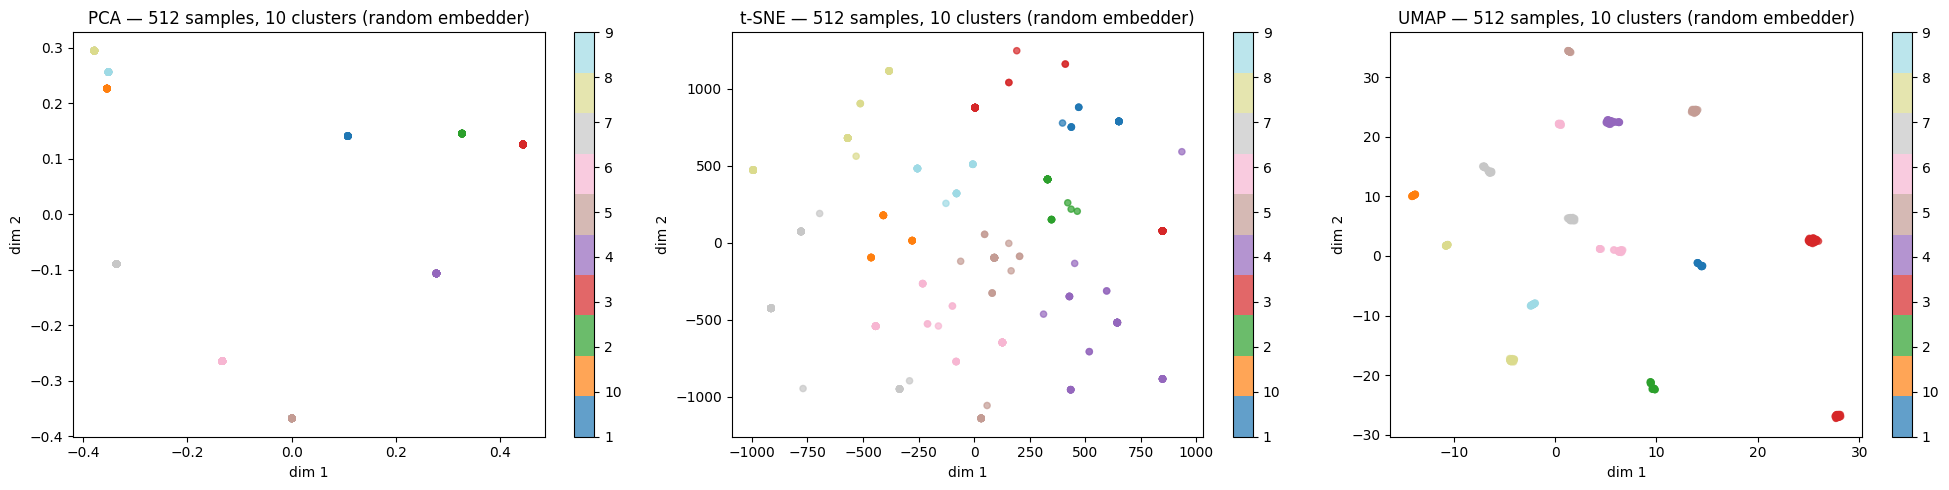

Shapes — X: (512, 768), labels: 512


In [38]:
#add a little noise
X_test = X_b32 #+ np.random.normal(0, 0.0000000000001, size=X_b1.shape) #this add noise to each row? 

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_test)

# t-SNE
tsne = TSNE(n_components=2, perplexity=10, random_state=42, max_iter=1000, learning_rate=400, init="pca", n_jobs=1)
X_tsne = tsne.fit_transform(X_test)

#
import umap
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_test)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
cmap = plt.cm.get_cmap("tab20", len(unique_labels))

for ax, X_red, title in zip(axes, [X_pca, X_tsne, X_umap], ["PCA", "t-SNE", "UMAP"]):
    sc = ax.scatter(X_red[:, 0], X_red[:, 1], c=colors, cmap=cmap, vmin=0, vmax=len(unique_labels)-1, alpha=0.7, s=20)
    cbar = plt.colorbar(sc, ax=ax, ticks=range(len(unique_labels)))
    cbar.set_ticklabels(unique_labels)
    ax.set_title(f"{title} — {N} samples, 10 clusters (random embedder)")
    ax.set_xlabel("dim 1")
    ax.set_ylabel("dim 2")

plt.tight_layout()
plt.show()
print(f"Shapes — X: {X_test.shape}, labels: {len(labels)}")

Checking answer='4' with 2315 rows
Found embedding for answer='4' with key=('human_lima_1', 'Robusto2_153', 6, 1)
Checking answer='3' with 5033 rows
Found embedding for answer='3' with key=('human_lima_2', 'Robusto2_153', 6, 1)
Checking answer='5' with 2379 rows
Found embedding for answer='5' with key=('human_lima_3', 'Robusto2_153', 6, 1)
Checking answer='9' with 857 rows
Found embedding for answer='9' with key=('human_lima_4', 'Robusto2_153', 6, 1)
Checking answer='7' with 2832 rows
Found embedding for answer='7' with key=('human_lima_5', 'Robusto2_153', 6, 1)
Checking answer='6' with 2714 rows
Found embedding for answer='6' with key=('human_lima_6', 'Robusto2_153', 6, 1)
Checking answer='8' with 2615 rows
Found embedding for answer='8' with key=('human_lima_9', 'Robusto2_153', 6, 1)
Checking answer='2' with 1231 rows
Found embedding for answer='2' with key=('human_nyc_13', 'Robusto2_153', 6, 1)
Checking answer='10' with 1111 rows
Found embedding for answer='10' with key=('human_nyc_

f:\robusto\vqa_analysis\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
f:\robusto\vqa_analysis\venv\Lib\site-packages\umap\umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


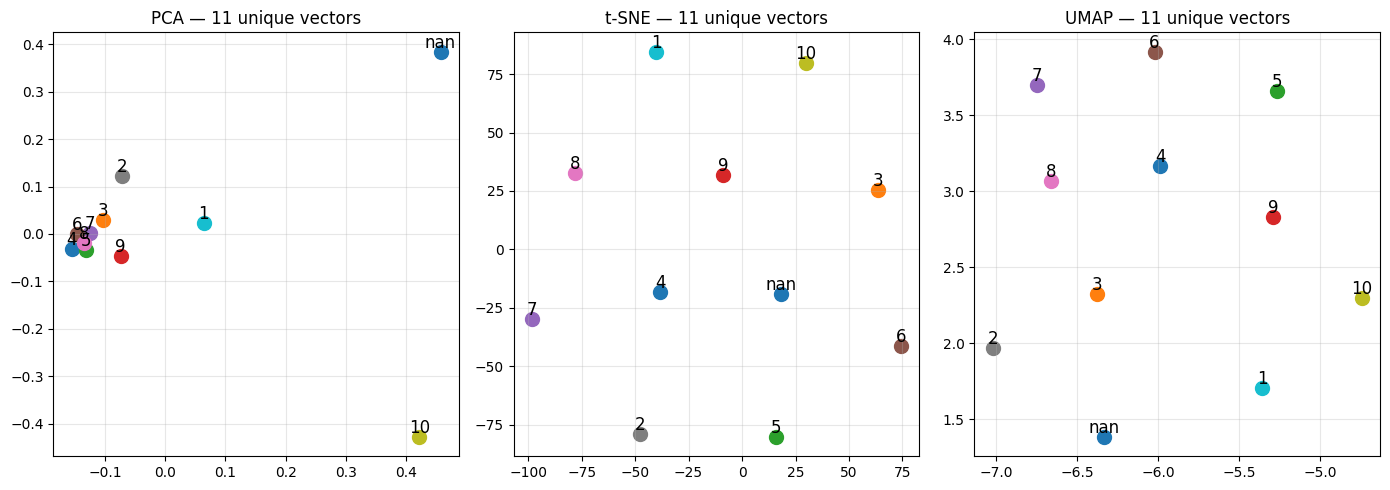

In [30]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 1. Obtener los 10 (+nan) embeddings únicos
unique_answers = df_b2["ANSWER"].unique()
unique_embs = []
unique_labels = []

#
embed_data = data_qwen  # Cambia a data_qwen si quieres analizar ese modelo

for ans in unique_answers:
    rows = df_b2[df_b2["ANSWER"] == ans]
    found = False
    print(f"Checking answer='{ans}' with {len(rows)} rows")
    for _, row in rows.iterrows():
        key = get_key(row)
        if key in embed_data:
            print(f"Found embedding for answer='{ans}' with key={key}")
            unique_embs.append(embed_data[key])
            unique_labels.append(str(ans))
            found = True
            break
        # else:
        #     print(f"SON Key {key} not found for answer='{ans}'")
    # if not found:
    #     print(f"SON No embedding found for answer='{ans}'")

unique_embs = np.array(unique_embs)
print(f"Shape: {unique_embs.shape}, labels: {unique_labels}")

# 2. PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(unique_embs)
print(f"Varianza explicada: {pca.explained_variance_ratio_.sum():.3f}")

# 3. t-SNE con perplexity << n (11 puntos → perplexity=3)
tsne = TSNE(n_components=2, perplexity=10, random_state=42, init="pca", n_jobs=1, max_iter=1000)
X_tsne = tsne.fit_transform(unique_embs)

# 4. umap (https://umap-learn.readthedocs.io/en/latest/basic_usage.html)
import umap
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(unique_embs) 

# 4. Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, X, title in zip(axes, [X_pca, X_tsne, X_umap], ["PCA", "t-SNE", "UMAP"]):
    for i, label in enumerate(unique_labels):
        ax.scatter(X[i, 0], X[i, 1], s=100)
        ax.annotate(label, (X[i, 0], X[i, 1]), fontsize=12, ha="center", va="bottom")
    ax.set_title(f"{title} — {len(unique_labels)} unique vectors")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
